## Clustering and Recommendation of Artisans/Small businesses

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from geopy.distance import great_circle

In [3]:
file_path = 'data/artisans_data.csv'
artisans_data = pd.read_csv(file_path)

In [4]:
artisans_data.head()

,Name,Address,Longitude,Latitude
0,Professional Locksmiths Association Of Nigeria...,"Banex Plaza, National Secretariat, Itire, 57 I...",3.502969,6.617908
1,GT LOCKSMITH KEY DUPLICATING PROGRAMMER FOB BA...,"Block 13/14, Igbo-Efon, Lekki - Epe Expy, Lekk...",3.411717,6.449054
2,Major Locksmith Nigeria Limited,"Kiosk, Tafawa Balewa Square Complex, Race Cour...",3.401122,6.445246
3,Phymocool Car AC Repair & Installation,"29 Balogun St, Yaba 100001, Lagos, Nigeria, La...",3.377044,6.534158
4,OFTECH,"162 Borno Way, Lagos, Lagos",3.376426,6.500482


In [5]:
artisans_data.rename(
    columns={
        "Name": "name",
        "Address": "address",
        "Longitude": "longitude",
        "Latitude": "latitude"
    }, inplace = True
)

In [6]:
artisans_data.head()

,name,address,longitude,latitude
0,Professional Locksmiths Association Of Nigeria...,"Banex Plaza, National Secretariat, Itire, 57 I...",3.502969,6.617908
1,GT LOCKSMITH KEY DUPLICATING PROGRAMMER FOB BA...,"Block 13/14, Igbo-Efon, Lekki - Epe Expy, Lekk...",3.411717,6.449054
2,Major Locksmith Nigeria Limited,"Kiosk, Tafawa Balewa Square Complex, Race Cour...",3.401122,6.445246
3,Phymocool Car AC Repair & Installation,"29 Balogun St, Yaba 100001, Lagos, Nigeria, La...",3.377044,6.534158
4,OFTECH,"162 Borno Way, Lagos, Lagos",3.376426,6.500482


In [7]:
artisans_geodata = gpd.GeoDataFrame(artisans_data, geometry=gpd.points_from_xy(artisans_data.longitude, artisans_data.latitude))

In [8]:
artisans_geodata.head()

,name,address,longitude,latitude,geometry
0,Professional Locksmiths Association Of Nigeria...,"Banex Plaza, National Secretariat, Itire, 57 I...",3.502969,6.617908,POINT (3.50297 6.61791)
1,GT LOCKSMITH KEY DUPLICATING PROGRAMMER FOB BA...,"Block 13/14, Igbo-Efon, Lekki - Epe Expy, Lekk...",3.411717,6.449054,POINT (3.41172 6.44905)
2,Major Locksmith Nigeria Limited,"Kiosk, Tafawa Balewa Square Complex, Race Cour...",3.401122,6.445246,POINT (3.40112 6.44525)
3,Phymocool Car AC Repair & Installation,"29 Balogun St, Yaba 100001, Lagos, Nigeria, La...",3.377044,6.534158,POINT (3.37704 6.53416)
4,OFTECH,"162 Borno Way, Lagos, Lagos",3.376426,6.500482,POINT (3.37643 6.50048)


In [9]:
coords = np.radians(artisans_geodata[['longitude', 'latitude']].values)

In [67]:
artisan_clusters = DBSCAN(eps=0.0001, min_samples=5, metric='haversine').fit(coords)

In [68]:
artisans_geodata['cluster'] = artisan_clusters.labels_

In [69]:
print("\nGeoDataFrame with Clusters:")
artisans_geodata.head()


GeoDataFrame with Clusters:


,name,address,longitude,latitude,geometry,cluster,distance
0,Professional Locksmiths Association Of Nigeria...,"Banex Plaza, National Secretariat, Itire, 57 I...",3.502969,6.617908,POINT (3.50297 6.61791),0,16638.425111
1,GT LOCKSMITH KEY DUPLICATING PROGRAMMER FOB BA...,"Block 13/14, Igbo-Efon, Lekki - Epe Expy, Lekk...",3.411717,6.449054,POINT (3.41172 6.44905),1,7519.510823
2,Major Locksmith Nigeria Limited,"Kiosk, Tafawa Balewa Square Complex, Race Cour...",3.401122,6.445246,POINT (3.40112 6.44525),1,7727.493480
3,Phymocool Car AC Repair & Installation,"29 Balogun St, Yaba 100001, Lagos, Nigeria, La...",3.377044,6.534158,POINT (3.37704 6.53416),2,2901.493632
4,OFTECH,"162 Borno Way, Lagos, Lagos",3.376426,6.500482,POINT (3.37643 6.50048),2,2500.199829


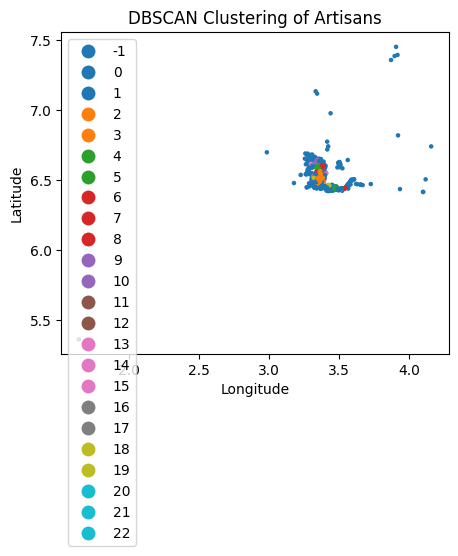

In [71]:
fig, ax = plt.subplots(figsize=(5, 5))
artisans_geodata.plot(column='cluster', categorical=True, legend=True, cmap='tab10', markersize=5, ax=ax)
plt.title('DBSCAN Clustering of Artisans')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [48]:
def recommend_artisans(artisans_geodata, service, longitude, latitude):
    # Find the artisan by name
    artisan = artisans_geodata[artisans_geodata['name'].str.contains(service, case=False, na=False)]
    
    if artisan.empty:
        print(f"No '{service}' found in your area")
        return pd.DataFrame()
    
    # Get the cluster of the found artisan
    cluster_label = artisan.iloc[0]['cluster']
    
    # Get all artisans in the same cluster
    cluster_artisans = artisans_geodata[artisans_geodata['cluster'] == cluster_label].copy()
    
    # Define the target coordinates
    target_coords = (latitude, longitude)
    
    # Calculate the distance from the target coordinates to each artisan
    cluster_artisans['distance'] = cluster_artisans.apply(lambda row: great_circle(target_coords, (row.geometry.y, row.geometry.x)).meters, axis=1)
    
    # Rank artisans by distance
    cluster_artisans_sorted = cluster_artisans.sort_values(by='distance').reset_index(drop=True)
    
    # Return a DataFrame with name, longitude, latitude, and distance
    return cluster_artisans_sorted[['name', 'longitude', 'latitude', 'distance']]


def recommend_artisans_by_proximity(gdf, longitude, latitude):
    target_coords = (latitude, longitude)
    
    # Calculate the distance from the target coordinates to each artisan
    gdf['distance'] = gdf.apply(lambda row: great_circle(target_coords, (row.geometry.y, row.geometry.x)).meters, axis=1)
    
    # Rank artisans by distance
    gdf_sorted = gdf.sort_values(by='distance').reset_index(drop=True)
    
    # Return a DataFrame with name, longitude, latitude, and distance
    return gdf_sorted[['name', 'longitude', 'latitude', 'distance']]

In [45]:
recommended_artisans = recommend_artisans(artisans_geodata, "", 3.3942,6.5144)

In [46]:
if not recommended_artisans.empty:
    print("\nRecommended Artisans:")
    print(recommended_artisans.head())


Recommended Artisans:
                                                name  longitude  latitude  \
0  Lubaz Tech | AC Repair in Ikorodu Lagos | Car ...   3.487608  6.591837   
1            DORIS BEAUTY LOUGE & NATURAL HAIR SALON   3.505962  6.593891   
2               BASIL INTERIOR DECORATION ENTERPRISE   3.501757  6.614212   
3   RABSON INTENSIVE FURNITURE & INTERIOR DECORATION   3.505212  6.610859   
4       Habobo's Launderette and drycleaing services   3.523468  6.585533   

       distance  
0  13439.380602  
1  15184.043534  
2  16258.720783  
3  16291.852858  
4  16324.325202  


In [50]:
recommended_by_proximity = recommend_artisans_by_proximity(artisans_geodata, 3.3942, 6.5144)

In [61]:
recommended_by_proximity.head(10)

,name,longitude,latitude,distance
0,Vicarol Catering,3.394633,6.514562,51.132583
1,E - Centre,3.391713,6.515830,317.435402
2,CITS (Centre for Information and Technology Sy...,3.394729,6.517231,320.225848
3,FastWash Laundromat,3.389826,6.518286,648.256176
4,REQUEST MECHANIC LTD,3.393397,6.506344,900.130904
5,Niyibram Communication Servicers,3.386200,6.512190,917.355838
6,Hoop Telecoms,3.388033,6.508538,942.911463
7,Bincom - Information Communication Technology ...,3.385325,6.512761,997.266530
8,Haryormidey foodies,3.385092,6.519105,1134.146066
9,XP Barbers,3.391940,6.503813,1203.382698


In [53]:
artisans_geodata.head(50)

,name,address,longitude,latitude,geometry,cluster,distance
0,Professional Locksmiths Association Of Nigeria...,"Banex Plaza, National Secretariat, Itire, 57 I...",3.502969,6.617908,POINT (3.50297 6.61791),0,16638.425111
1,GT LOCKSMITH KEY DUPLICATING PROGRAMMER FOB BA...,"Block 13/14, Igbo-Efon, Lekki - Epe Expy, Lekk...",3.411717,6.449054,POINT (3.41172 6.44905),1,7519.510823
2,Major Locksmith Nigeria Limited,"Kiosk, Tafawa Balewa Square Complex, Race Cour...",3.401122,6.445246,POINT (3.40112 6.44525),1,7727.493480
3,Phymocool Car AC Repair & Installation,"29 Balogun St, Yaba 100001, Lagos, Nigeria, La...",3.377044,6.534158,POINT (3.37704 6.53416),1,2901.493632
4,OFTECH,"162 Borno Way, Lagos, Lagos",3.376426,6.500482,POINT (3.37643 6.50048),1,2500.199829
5,COOL PLUS,"Sura Shopping Complex Simpson Street, LAGOS, L...",3.404260,6.454463,POINT (3.40426 6.45446),1,6756.741263
6,Technoton Ltd: Air Conditioning Contractor in ...,"5 Adeola Odeku St, Victoria Island, Lagos 1061...",3.413795,6.430618,POINT (3.41379 6.43062),1,9564.407256
7,Autopholex technical car air conditioner,"down down PGH, Ebute-metta Oyingbo, Ondo St, L...",3.384613,6.485278,POINT (3.38461 6.48528),1,3407.070148
8,Technoton Ltd: Air Conditioning Contractor in ...,"9, Ademola Street, Off Awolowo Rd, Ikoyi 10123...",3.417204,6.441885,POINT (3.4172 6.44188),1,8454.403665
9,Satek Nigeria Limited,"8 10 Ilupeju Bye Pass, Lagos, Lagos State",3.356480,6.544230,POINT (3.35648 6.54423),1,5326.044625
